In [1]:
1+1

2

In [6]:
from pathlib import Path
import pandas as pd

BASE = Path('./brain_only')
subjects = sorted([p.name for p in BASE.iterdir() if p.is_dir()])

MODALITIES = {
    't1':     't1_brain.nii.gz',
    't2_axi': 't2_axi_brain.nii.gz',
    't2_cor': 't2_cor_brain.nii.gz',
    'flair':  'flair_brain.nii.gz',
    'mask':   'brain_mask.nii.gz',
}

rows = []
for uid in subjects:
    row = {'subject': uid}
    for mod, fname in MODALITIES.items():
        row[mod] = (BASE / uid / fname).exists()
    rows.append(row)

df = pd.DataFrame(rows)

print(f'Total subjects: {len(df)}')
print()
print('=== Modality availability ===')
for mod in MODALITIES:
    n = df[mod].sum()
    bar = '#' * int(n / len(df) * 40)
    print(f'  {mod:<8}: {n:>3} / {len(df)}  ({n/len(df)*100:.1f}%)  {bar}')

print()
print('=== Modality combination breakdown ===')
combos = df[list(MODALITIES.keys())].apply(tuple, axis=1).value_counts()
for combo, cnt in combos.items():
    labels = [m for m, has in zip(MODALITIES.keys(), combo) if has]
    print(f'  {cnt:>3}x  {", ".join(labels)}')

print()
print(f"Subjects with ALL 5 modalities: {df[list(MODALITIES.keys())].all(axis=1).sum()}")


Total subjects: 450

=== Modality availability ===
  t1      : 450 / 450  (100.0%)  ########################################
  t2_axi  : 423 / 450  (94.0%)  #####################################
  t2_cor  : 211 / 450  (46.9%)  ##################
  flair   : 358 / 450  (79.6%)  ###############################
  mask    : 450 / 450  (100.0%)  ########################################

=== Modality combination breakdown ===
  200x  t1, t2_axi, flair, mask
  155x  t1, t2_axi, t2_cor, flair, mask
   42x  t1, t2_axi, t2_cor, mask
   26x  t1, t2_axi, mask
   14x  t1, t2_cor, mask
   10x  t1, mask
    3x  t1, flair, mask

Subjects with ALL 5 modalities: 155


In [19]:
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
import random

random.seed(42)

BASE = Path('./brain_only')
subjects = sorted([p.name for p in BASE.iterdir() if p.is_dir()])
sample = random.sample(subjects, 100)

def classify_acquisition(nifti_path):
    img = nib.load(nifti_path)
    zooms = img.header.get_zooms()
    shape = img.shape
    dx, dy, dz = zooms[:3]
    H, W, D = shape
    thick_slice  = dz > 2.5
    anisotropy   = dz / ((dx + dy) / 2)
    anisotropic  = anisotropy > 2.0
    few_slices   = D < 60
    votes = sum([thick_slice, anisotropic, few_slices])
    return "thick" if votes >= 2 else "3d"

rows = []
for uid in sample:
    p = BASE / uid / 't1_brain.nii.gz'
    if not p.exists():
        continue
    nii = nib.load(p)
    H, W, D = nii.shape
    dx, dy, dz = [round(float(z), 3) for z in nii.header.get_zooms()[:3]]
    pop = classify_acquisition(p)
    rows.append({'subject': uid, 'pop': pop,
                 'H': H, 'W': W, 'D': D,
                 'dx_mm': dx, 'dy_mm': dy, 'dz_mm': dz,
                 'anisotropy': round(dz / ((dx + dy) / 2), 2)})

df = pd.DataFrame(rows)

print(f'Loaded {len(df)} subjects')
print()
print("=== Population split (voting classifier) ===")
print(df['pop'].value_counts().to_string())
print()
print('=== Shape (H x W x D) ===')
print(df[['H','W','D']].describe().round(1).to_string())
print()
print('=== Voxel size (mm) ===')
print(df[['dx_mm','dy_mm','dz_mm','anisotropy']].describe().round(3).to_string())
print()
print('=== Full table ===')
print(df.to_string(index=False))


Loaded 100 subjects

=== Population split (voting classifier) ===
pop
3d       62
thick    38

=== Shape (H x W x D) ===
           H      W      D
count  100.0  100.0  100.0
mean   251.1  388.3  243.1
std    127.4  128.3  208.0
min    150.0  144.0   20.0
25%    168.8  256.0   25.0
50%    204.0  320.0  224.0
75%    256.0  512.0  512.0
max    512.0  560.0  560.0

=== Voxel size (mm) ===
         dx_mm    dy_mm    dz_mm  anisotropy
count  100.000  100.000  100.000     100.000
mean     0.894    0.681    2.767       4.247
std      0.241    0.225    2.699       4.930
min      0.449    0.446    0.446       0.540
25%      0.799    0.469    0.469       0.640
50%      0.977    0.750    0.938       0.985
75%      1.000    0.859    6.000       6.980
max      1.200    1.500    7.200      15.590

=== Full table ===
   subject   pop   H   W   D  dx_mm  dy_mm  dz_mm  anisotropy
QOD3XG6R6P thick 204 256  28  0.859  0.859  6.000        6.98
5YKGMTUWHZ thick 204 256  26  0.859  0.859  6.000        6.98


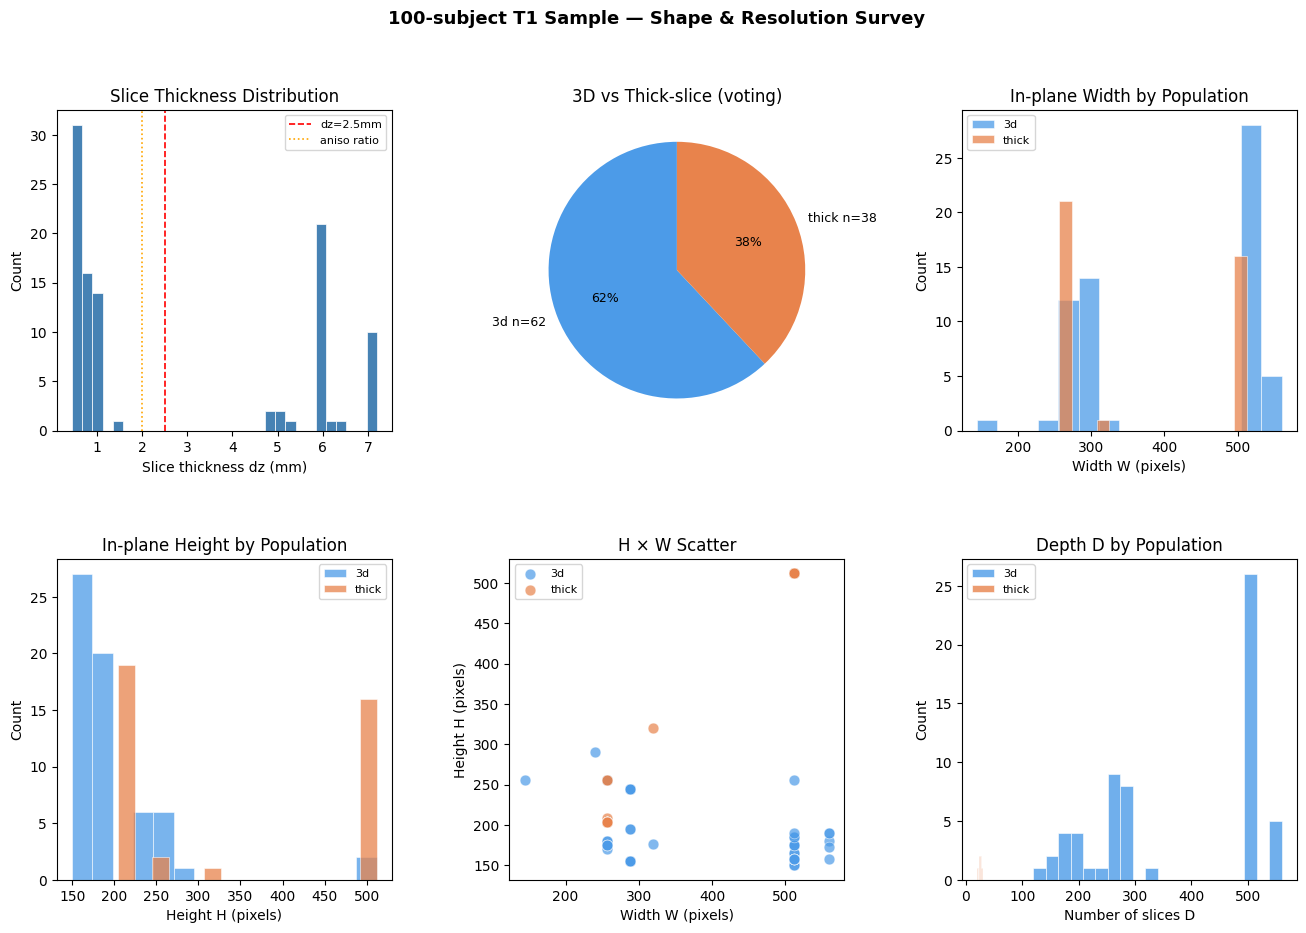

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

COLORS = {"3d": "#4c9be8", "thick": "#e8834c"}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Slice thickness histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["dz_mm"], bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
ax1.axvline(2.5, color="red",    linestyle="--", linewidth=1.2, label="dz=2.5mm")
ax1.axvline(2.0, color="orange", linestyle=":",  linewidth=1.2, label="aniso ratio")
ax1.set_xlabel("Slice thickness dz (mm)")
ax1.set_ylabel("Count")
ax1.set_title("Slice Thickness Distribution")
ax1.legend(fontsize=8)

# 2. Population split pie
ax2 = fig.add_subplot(gs[0, 1])
vc = df["pop"].value_counts()
ax2.pie(vc.values,
        labels=[f"{k} n={v}" for k,v in vc.items()],
        autopct="%1.0f%%",
        colors=[COLORS.get(k, "gray") for k in vc.index],
        startangle=90, textprops={"fontsize": 9})
ax2.set_title("3D vs Thick-slice (voting)")

# 3. In-plane width W
ax3 = fig.add_subplot(gs[0, 2])
for pop, grp in df.groupby("pop"):
    ax3.hist(grp["W"], bins=15, alpha=0.75, color=COLORS[pop],
             edgecolor="white", linewidth=0.5, label=pop)
ax3.set_xlabel("Width W (pixels)")
ax3.set_ylabel("Count")
ax3.set_title("In-plane Width by Population")
ax3.legend(fontsize=8)

# 4. In-plane height H
ax4 = fig.add_subplot(gs[1, 0])
for pop, grp in df.groupby("pop"):
    ax4.hist(grp["H"], bins=15, alpha=0.75, color=COLORS[pop],
             edgecolor="white", linewidth=0.5, label=pop)
ax4.set_xlabel("Height H (pixels)")
ax4.set_ylabel("Count")
ax4.set_title("In-plane Height by Population")
ax4.legend(fontsize=8)

# 5. H x W scatter coloured by pop
ax5 = fig.add_subplot(gs[1, 1])
for pop, grp in df.groupby("pop"):
    ax5.scatter(grp["W"], grp["H"], c=COLORS[pop], alpha=0.7,
                edgecolors="white", linewidth=0.4, s=60, label=pop)
ax5.set_xlabel("Width W (pixels)")
ax5.set_ylabel("Height H (pixels)")
ax5.set_title("H × W Scatter")
ax5.legend(fontsize=8)

# 6. Depth D by population
ax6 = fig.add_subplot(gs[1, 2])
for pop, grp in df.groupby("pop"):
    ax6.hist(grp["D"], bins=20, alpha=0.8, color=COLORS[pop],
             edgecolor="white", linewidth=0.5, label=pop)
ax6.set_xlabel("Number of slices D")
ax6.set_ylabel("Count")
ax6.set_title("Depth D by Population")
ax6.legend(fontsize=8)

plt.suptitle("100-subject T1 Sample — Shape & Resolution Survey", fontsize=13, fontweight="bold")
plt.show()


=== Empty slice rate summary ===
[3d]  n=62 subjects
  Total slices : 23372
  Empty slices : 10411
  Usable slices: 12961
  Empty %/subj : mean=42.8%  min=18.5%  max=100.0%
  Usable/subj  : mean=209.0  min=0  max=311
[thick]  n=38 subjects
  Total slices : 936
  Empty slices : 122
  Usable slices: 814
  Empty %/subj : mean=12.4%  min=0.0%  max=26.9%
  Usable/subj  : mean=21.4  min=18  max=27


/tmp/ipykernel_19223/3197323650.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=["3D volumetric","Thick-slice"],


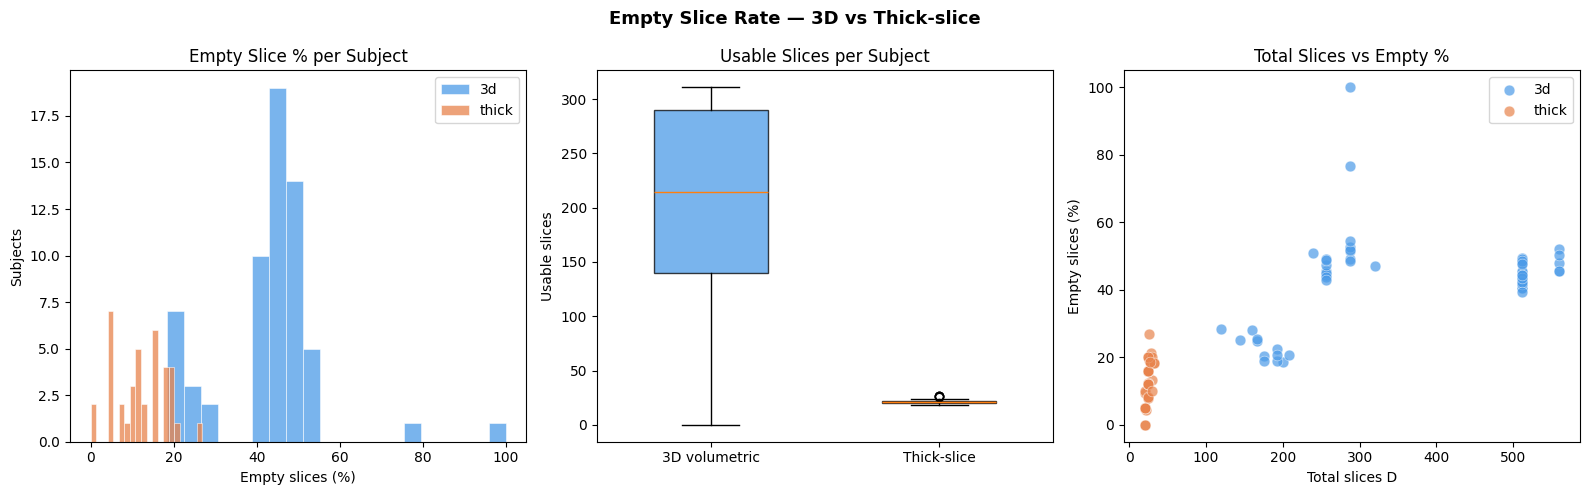

In [22]:
# ── Empty slice rate — 3D vs Thick-slice ────────────────────────────────────
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE     = Path('./brain_only')
MIN_FILL = 0.01

COLORS = {"3d": "#4c9be8", "thick": "#e8834c"}

rows = []
for _, row in df.iterrows():
    p   = BASE / row["subject"] / "t1_brain.nii.gz"
    nii = nib.load(p)
    H, W, D = nii.shape
    data    = nii.get_fdata(dtype=np.float32)
    empty   = sum(1 for z in range(D) if np.count_nonzero(data[..., z]) / (H * W) < MIN_FILL)
    usable  = D - empty
    rows.append({
        "subject":      row["subject"],
        "pop":          row["pop"],
        "dz":           row["dz_mm"],
        "anisotropy":   row["anisotropy"],
        "total_slices": D,
        "empty_slices": empty,
        "usable_slices":usable,
        "empty_pct":    round(empty / D * 100, 1),
    })

dfe = pd.DataFrame(rows)

print("=== Empty slice rate summary ===")
for pop, grp in dfe.groupby("pop"):
    print(f"[{pop}]  n={len(grp)} subjects")
    print(f"  Total slices : {grp['total_slices'].sum()}")
    print(f"  Empty slices : {grp['empty_slices'].sum()}")
    print(f"  Usable slices: {grp['usable_slices'].sum()}")
    print(f"  Empty %/subj : mean={grp['empty_pct'].mean():.1f}%  "
          f"min={grp['empty_pct'].min():.1f}%  max={grp['empty_pct'].max():.1f}%")
    print(f"  Usable/subj  : mean={grp['usable_slices'].mean():.1f}  "
          f"min={grp['usable_slices'].min()}  max={grp['usable_slices'].max()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Empty % histogram
for pop, grp in dfe.groupby("pop"):
    axes[0].hist(grp["empty_pct"], bins=20, alpha=0.75, color=COLORS[pop],
                 edgecolor="white", linewidth=0.5, label=pop)
axes[0].set_xlabel("Empty slices (%)")
axes[0].set_ylabel("Subjects")
axes[0].set_title("Empty Slice % per Subject")
axes[0].legend()

# 2. Usable slices boxplot
data_box = [dfe[dfe["pop"]==p]["usable_slices"].values for p in ["3d","thick"]]
bp = axes[1].boxplot(data_box, labels=["3D volumetric","Thick-slice"],
                     patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [COLORS["3d"], COLORS["thick"]]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_ylabel("Usable slices")
axes[1].set_title("Usable Slices per Subject")

# 3. Total slices vs empty %
for pop, grp in dfe.groupby("pop"):
    axes[2].scatter(grp["total_slices"], grp["empty_pct"], color=COLORS[pop],
                    alpha=0.7, edgecolors="white", linewidth=0.4, s=60, label=pop)
axes[2].set_xlabel("Total slices D")
axes[2].set_ylabel("Empty slices (%)")
axes[2].set_title("Total Slices vs Empty %")
axes[2].legend()

plt.suptitle("Empty Slice Rate — 3D vs Thick-slice", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


=== Most empty subjects ===
   subject pop    dz  total_slices  empty_slices  empty_pct
X4DSUZALBB  3d 0.889           288           288      100.0
IDPGHXRT4I  3d 0.833           288           221       76.7
T4EGCFKCES  3d 0.889           288           157       54.5
BXRSAQ7XN3  3d 0.889           288           152       52.8


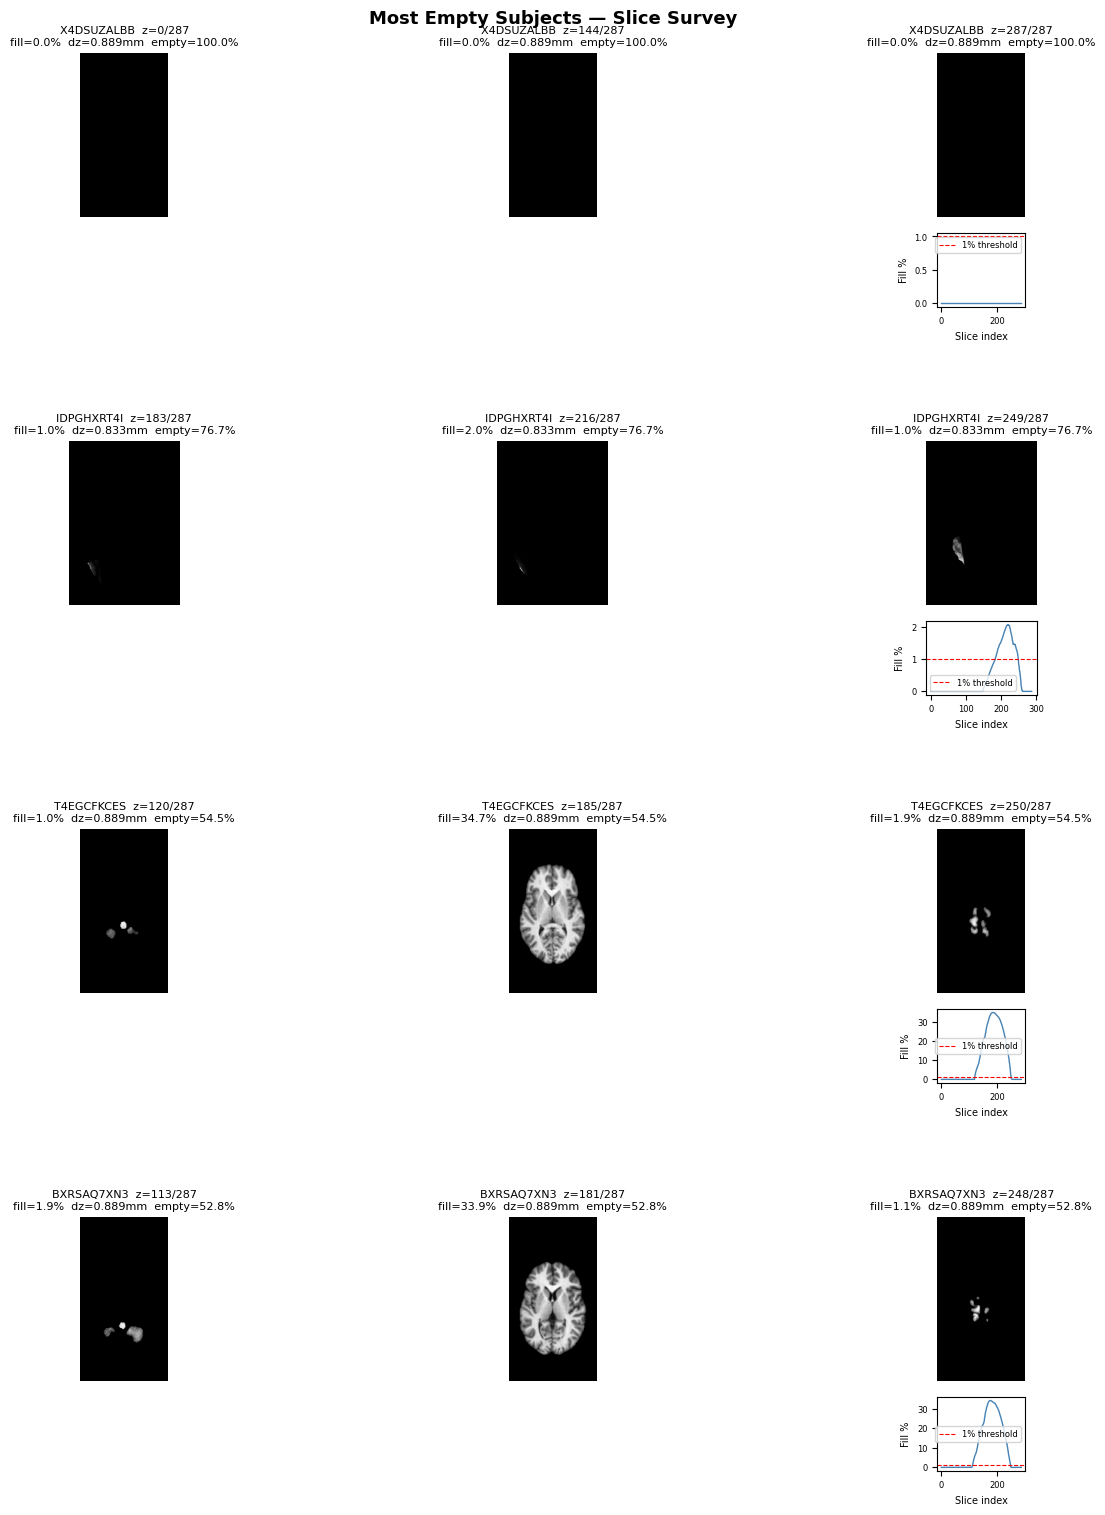

In [23]:
# ── Investigate high empty-slice subjects ────────────────────────────────────
# dfe is from cell 4
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('./brain_only')

# Top 4 subjects by empty %
top_empty = dfe.nlargest(4, "empty_pct")[["subject","pop","dz","total_slices","empty_slices","empty_pct"]]
print("=== Most empty subjects ===")
print(top_empty.to_string(index=False))

fig, axes = plt.subplots(len(top_empty), 3, figsize=(14, 4 * len(top_empty)))
fig.suptitle("Most Empty Subjects — Slice Survey", fontsize=13, fontweight="bold")

for row_i, (_, subj) in enumerate(top_empty.iterrows()):
    uid = subj["subject"]
    nii = nib.load(BASE / uid / "t1_brain.nii.gz")
    H, W, D = nii.shape
    data = nii.get_fdata(dtype=np.float32)

    # fill rate per slice
    fill = np.array([np.count_nonzero(data[..., z]) / (H * W) for z in range(D)])

    # pick 3 representative slices: first usable, middle, last usable
    usable_idx = np.where(fill >= 0.01)[0]
    if len(usable_idx) == 0:
        picks = [0, D//2, D-1]
    else:
        picks = [usable_idx[0], usable_idx[len(usable_idx)//2], usable_idx[-1]]

    for col_i, z in enumerate(picks):
        ax = axes[row_i, col_i]
        ax.imshow(data[..., z].T, cmap="gray", origin="lower", aspect="equal")
        ax.set_title(f"{uid}  z={z}/{D-1}\nfill={fill[z]*100:.1f}%  dz={subj['dz']}mm  empty={subj['empty_pct']}%", fontsize=8)
        ax.axis("off")

    # add fill-rate profile as inset on last column
    ax = axes[row_i, 2]
    ax2 = ax.inset_axes([0.0, -0.55, 1.0, 0.45])
    ax2.plot(fill * 100, color="steelblue", linewidth=1)
    ax2.axhline(1, color="red", linestyle="--", linewidth=0.8, label="1% threshold")
    ax2.set_xlabel("Slice index", fontsize=7)
    ax2.set_ylabel("Fill %", fontsize=7)
    ax2.tick_params(labelsize=6)
    ax2.legend(fontsize=6)

plt.tight_layout()
plt.show()


=== Thick-slice subjects sorted by empty % ===
   subject   dz  total_slices  empty_slices  usable_slices  empty_pct
RD652UUPXR 6.00            26             7             19       26.9
QOD3XG6R6P 6.00            28             6             22       21.4
BAJRJ3WVO2 6.00            25             5             20       20.0
GRBXST3BAM 5.00            30             6             24       20.0
7FOPIHRPBU 6.00            25             5             20       20.0
5YKGMTUWHZ 6.00            26             5             21       19.2
BTSJDX34JH 6.00            27             5             22       18.5
RGCCGGKVXI 6.00            27             5             22       18.5
GAJ5YDPC34 5.20            33             6             27       18.2
BL7MFVN4BT 4.80            33             6             27       18.2
DKG5B3VAAN 6.00            25             4             21       16.0
AQZ5WZSYRB 6.00            25             4             21       16.0
D7WXPA6AAU 6.00            25             4

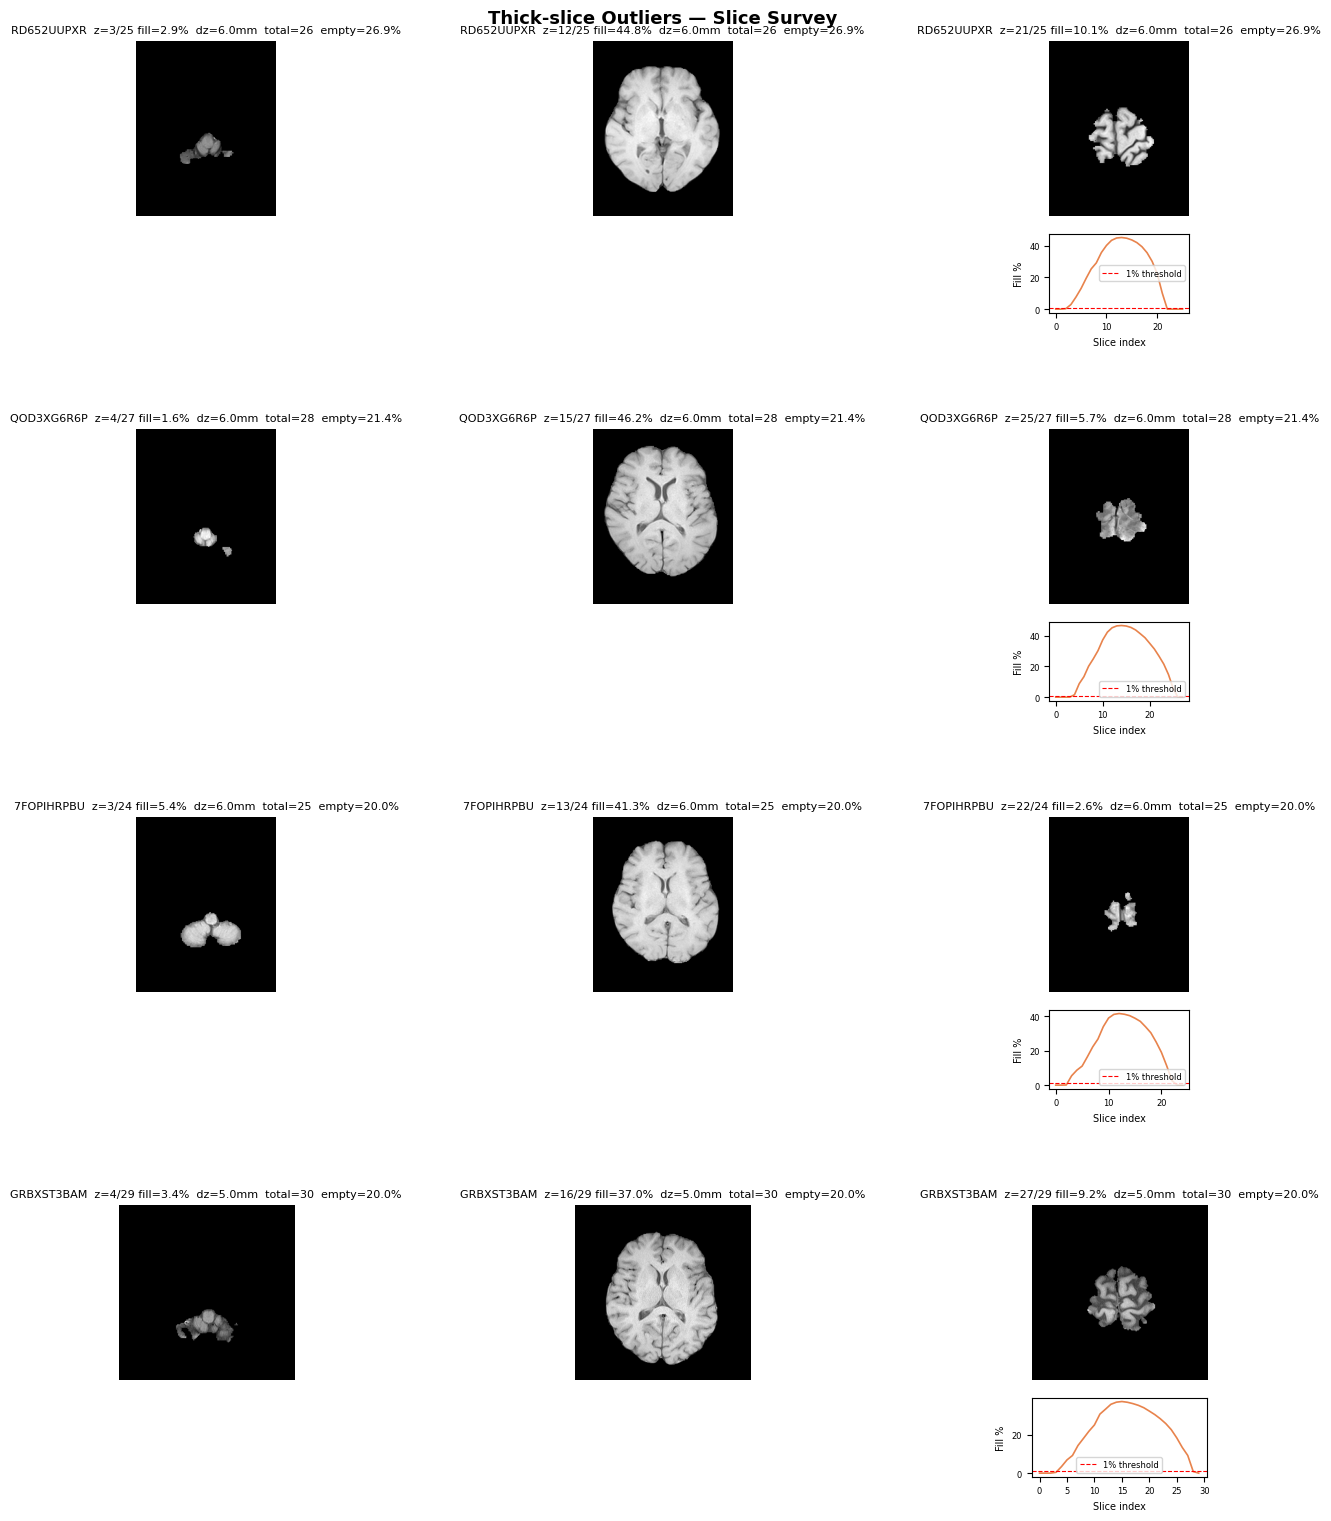

In [24]:
# ── Outliers in thick-slice (2D) population ──────────────────────────────────
# dfe is from cell 4
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('./brain_only')

thick = dfe[dfe["pop"] == "thick"].copy()

print("=== Thick-slice subjects sorted by empty % ===")
print(thick[["subject","dz","total_slices","empty_slices","usable_slices","empty_pct"]]
      .sort_values("empty_pct", ascending=False).to_string(index=False))

# Outliers = top 4 by empty % in thick population
outliers = thick.nlargest(4, "empty_pct")

fig, axes = plt.subplots(len(outliers), 3, figsize=(14, 4 * len(outliers)))
if len(outliers) == 1:
    axes = axes[None, :]
fig.suptitle("Thick-slice Outliers — Slice Survey", fontsize=13, fontweight="bold")

for row_i, (_, subj) in enumerate(outliers.iterrows()):
    uid = subj["subject"]
    nii = nib.load(BASE / uid / "t1_brain.nii.gz")
    H, W, D = nii.shape
    data = nii.get_fdata(dtype=np.float32)

    fill = np.array([np.count_nonzero(data[..., z]) / (H * W) for z in range(D)])
    usable_idx = np.where(fill >= 0.01)[0]

    if len(usable_idx) == 0:
        picks = [0, D//2, D-1]
    else:
        picks = [usable_idx[0], usable_idx[len(usable_idx)//2], usable_idx[-1]]

    for col_i, z in enumerate(picks):
        ax = axes[row_i, col_i]
        ax.imshow(data[..., z].T, cmap="gray", origin="lower", aspect="equal")
        ax.set_title(
            f"{uid}  z={z}/{D-1} "
            f"fill={fill[z]*100:.1f}%  dz={subj['dz']}mm  "
            f"total={subj['total_slices']}  empty={subj['empty_pct']}%",
            fontsize=8,
        )
        ax.axis("off")

    # fill-rate profile as inset
    ax2 = axes[row_i, 2].inset_axes([0.0, -0.55, 1.0, 0.45])
    ax2.plot(fill * 100, color="#e8834c", linewidth=1.2)
    ax2.axhline(1, color="red", linestyle="--", linewidth=0.8, label="1% threshold")
    ax2.set_xlabel("Slice index", fontsize=7)
    ax2.set_ylabel("Fill %", fontsize=7)
    ax2.tick_params(labelsize=6)
    ax2.legend(fontsize=6)

plt.tight_layout()
plt.show()


In [25]:
# ── Thick-slice subjects with >100 total slices — why? ───────────────────────
# dfe is from cell 4
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('./brain_only')

# Find thick-slice subjects with >100 total slices
suspects = dfe[(dfe["pop"] == "thick") & (dfe["total_slices"] > 100)].copy()
print(f"Thick-slice subjects with >100 slices: {len(suspects)}")
print(suspects[["subject","dz","total_slices","empty_slices","usable_slices","empty_pct"]].to_string(index=False))

fig, axes = plt.subplots(len(suspects), 4, figsize=(16, 4.5 * len(suspects)))
if len(suspects) == 1:
    axes = axes[None, :]
fig.suptitle("Thick-slice Subjects with >100 Slices", fontsize=13, fontweight="bold")

for row_i, (_, subj) in enumerate(suspects.iterrows()):
    uid  = subj["subject"]
    nii  = nib.load(BASE / uid / "t1_brain.nii.gz")
    H, W, D = nii.shape
    zooms = nii.header.get_zooms()
    data = nii.get_fdata(dtype=np.float32)

    fill = np.array([np.count_nonzero(data[..., z]) / (H * W) for z in range(D)])
    usable_idx = np.where(fill >= 0.01)[0]

    # Show: first usable, 25%, 50%, 75% through usable range
    if len(usable_idx) >= 4:
        picks = [usable_idx[0],
                 usable_idx[len(usable_idx)//4],
                 usable_idx[len(usable_idx)//2],
                 usable_idx[3*len(usable_idx)//4]]
    else:
        picks = np.linspace(0, D-1, 4, dtype=int).tolist()

    for col_i, z in enumerate(picks):
        ax = axes[row_i, col_i]
        ax.imshow(data[..., z].T, cmap="gray", origin="lower", aspect="equal")
        ax.set_title(
            f"z={z}/{D-1}  fill={fill[z]*100:.1f}%\n"
            f"shape=({H},{W},{D})  dz={round(float(zooms[2]),2)}mm",
            fontsize=7.5)
        ax.axis("off")

    # replace last image with fill-rate profile
    ax = axes[row_i, 3]
    ax.cla()
    ax.plot(fill * 100, color="#e8834c", linewidth=1.2)
    ax.axhline(1, color="red", linestyle="--", linewidth=0.8, label="1% threshold")
    ax.fill_between(range(D), fill * 100, alpha=0.2, color="#e8834c")
    ax.set_xlabel("Slice index", fontsize=8)
    ax.set_ylabel("Fill %", fontsize=8)
    ax.set_title(f"{uid} total={D}  usable={len(usable_idx)}  empty={subj['empty_pct']}%", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


Thick-slice subjects with >100 slices: 0
Empty DataFrame
Columns: [subject, dz, total_slices, empty_slices, usable_slices, empty_pct]
Index: []


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x0 with 0 Axes>

In [31]:
# ── Step 1: Subject filtering — 3D only, drop empty + outliers ──────────────
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path

BASE          = Path('./brain_only')
MIN_FILL      = 0.01   # slice-level: <1% non-zero → empty slice
MAX_FILL_MIN  = 0.15   # volume-level: peak fill must be >15% (catches partial brains)
MIN_USABLE_R  = 0.10   # volume-level: usable/total must be >10% for 3D scans

def classify_acquisition(nifti_path):
    img  = nib.load(nifti_path)
    zooms = img.header.get_zooms()
    dx, dy, dz = zooms[:3]
    D = img.shape[2]
    thick_slice = dz > 2.5
    anisotropy  = dz / ((dx + dy) / 2) > 2.0
    few_slices  = D < 60
    return "thick" if sum([thick_slice, anisotropy, few_slices]) >= 2 else "3d"

subjects = sorted([p.name for p in BASE.iterdir() if p.is_dir()])
print(f"Total subjects on disk: {len(subjects)}")

rows = []
for uid in subjects:
    p = BASE / uid / "t1_brain.nii.gz"
    if not p.exists():
        rows.append({"subject": uid, "pop": None, "reason": "no_t1",
                     "total_slices": 0, "usable_slices": 0, "max_fill": 0})
        continue

    pop = classify_acquisition(p)
    if pop == "thick":
        rows.append({"subject": uid, "pop": pop, "reason": "thick_slice",
                     "dz": round(float(nib.load(p).header.get_zooms()[2]),3),
                     "total_slices": nib.load(p).shape[2], "usable_slices": 0, "max_fill": 0})
        continue

    nii  = nib.load(p)
    H, W, D = nii.shape
    dz   = round(float(nii.header.get_zooms()[2]), 3)
    data = nii.get_fdata(dtype=np.float32)

    fills       = np.array([np.count_nonzero(data[..., z]) / (H * W) for z in range(D)])
    max_fill    = fills.max()
    usable      = int((fills >= MIN_FILL).sum())
    usable_ratio = usable / D

    if usable == 0:
        reason = "empty_volume"
    elif max_fill < MAX_FILL_MIN:
        reason = "low_peak_fill"      # partial brain / failed extraction
    elif usable_ratio < MIN_USABLE_R:
        reason = "low_usable_ratio"   # brain in tiny fraction of FOV
    else:
        reason = "ok"

    rows.append({"subject": uid, "pop": pop, "reason": reason, "dz": dz,
                 "total_slices": D, "usable_slices": usable,
                 "max_fill": round(float(max_fill), 3),
                 "usable_ratio": round(usable_ratio, 3)})

df_all = pd.DataFrame(rows)

print()
print("=== Classification breakdown ===")
print(df_all["reason"].value_counts().to_string())

df_3d      = df_all[df_all["reason"] == "ok"].reset_index(drop=True)
df_dropped = df_all[df_all["reason"] != "ok"]

print()
print(f"Kept  (3D, clean) : {len(df_3d)} subjects")
print(f"Dropped           : {len(df_dropped)} subjects")
print()
print("=== Dropped 3D subjects (non-thick) ===")
non_thick_dropped = df_dropped[df_dropped["pop"] == "3d"]
print(non_thick_dropped[["subject","reason","dz","total_slices","usable_slices","max_fill"]].to_string(index=False))

print()
print("=== Kept subjects — usable slice stats ===")
print(df_3d["usable_slices"].describe().round(1).to_string())
print(f"Total usable slices: {df_3d['usable_slices'].sum():,}")


Total subjects on disk: 450

=== Classification breakdown ===
reason
ok               251
thick_slice      195
low_peak_fill      2
empty_volume       2

Kept  (3D, clean) : 251 subjects
Dropped           : 199 subjects

=== Dropped 3D subjects (non-thick) ===
   subject        reason    dz  total_slices  usable_slices  max_fill
2CO3ODNYCK low_peak_fill 0.977           256             22     0.098
IDPGHXRT4I low_peak_fill 0.833           288             67     0.021
RFBOX2XT3P  empty_volume 0.469           512              0     0.000
X4DSUZALBB  empty_volume 0.889           288              0     0.000

=== Kept subjects — usable slice stats ===
count    251.0
mean     215.4
std       73.2
min       84.0
25%      141.0
50%      263.0
75%      282.0
max      336.0
Total usable slices: 54,058


Subject : 2CO3ODNYCK
Shape   : (192, 256, 256)
dz      : 0.977 mm
Usable slices (>1% fill): 22
Usable range : z=77 – z=98
Max fill     : 9.8%  at z=90


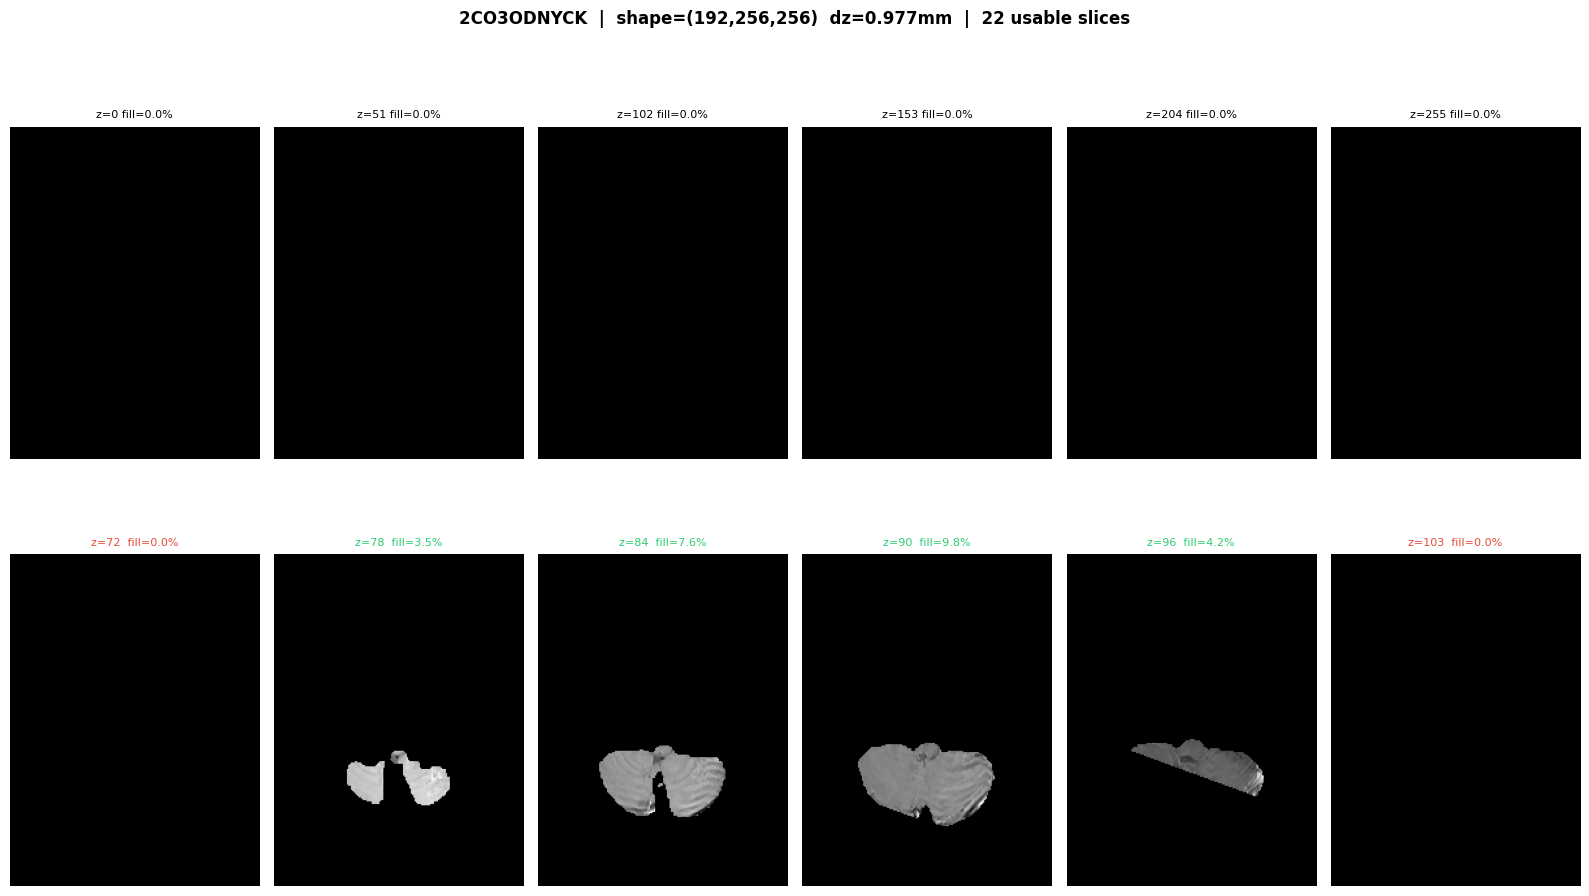

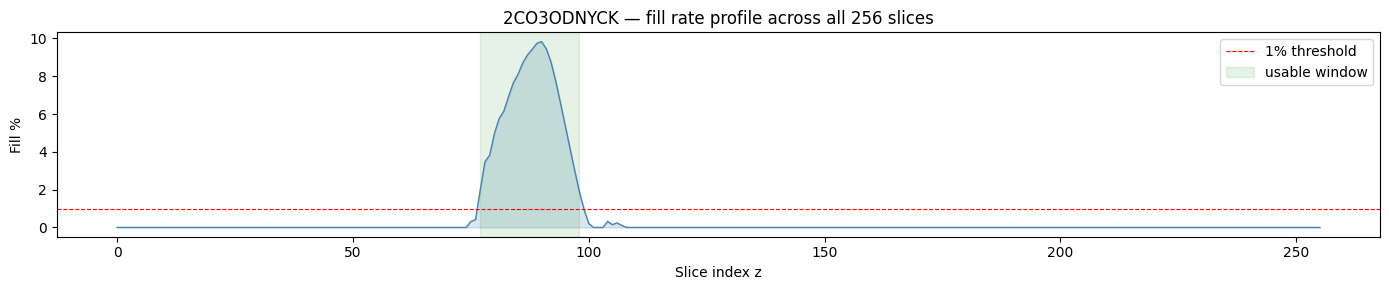

In [30]:
# ── Investigate 3D subject with only 22 usable slices: 2CO3ODNYCK ───────────
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('./brain_only')
uid  = '2CO3ODNYCK'

nii  = nib.load(BASE / uid / 't1_brain.nii.gz')
H, W, D = nii.shape
dz   = round(float(nii.header.get_zooms()[2]), 3)
data = nii.get_fdata(dtype=np.float32)

fill = np.array([np.count_nonzero(data[..., z]) / (H * W) for z in range(D)])
usable_idx = np.where(fill >= 0.01)[0]

print(f"Subject : {uid}")
print(f"Shape   : ({H}, {W}, {D})")
print(f"dz      : {dz} mm")
print(f"Usable slices (>1% fill): {len(usable_idx)}")
print(f"Usable range : z={usable_idx[0]} – z={usable_idx[-1]}")
print(f"Max fill     : {fill.max()*100:.1f}%  at z={fill.argmax()}")

fig = plt.figure(figsize=(16, 10))
fig.suptitle(f"{uid}  |  shape=({H},{W},{D})  dz={dz}mm  |  {len(usable_idx)} usable slices",
             fontsize=12, fontweight="bold")

# Row 1: evenly spaced slices across full volume
ax_top = [fig.add_subplot(2, 6, i+1) for i in range(6)]
sample_z = np.linspace(0, D-1, 6, dtype=int)
for ax, z in zip(ax_top, sample_z):
    ax.imshow(data[..., z].T, cmap="gray", origin="lower", aspect="equal")
    ax.set_title(f"z={z} fill={fill[z]*100:.1f}%", fontsize=8)
    ax.axis("off")

# Row 2: slices around the usable window
ax_bot = [fig.add_subplot(2, 6, i+7) for i in range(6)]
# show a few before, during and after the usable window
window_start = max(0, usable_idx[0] - 5)
window_end   = min(D-1, usable_idx[-1] + 5)
window_z = np.linspace(window_start, window_end, 6, dtype=int)
for ax, z in zip(ax_bot, window_z):
    color = "#2ecc71" if fill[z] >= 0.01 else "#e74c3c"
    ax.imshow(data[..., z].T, cmap="gray", origin="lower", aspect="equal")
    ax.set_title(f"z={z}  fill={fill[z]*100:.1f}%", fontsize=8, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Fill-rate profile
fig2, ax = plt.subplots(figsize=(14, 3))
ax.plot(fill * 100, color="steelblue", linewidth=1)
ax.axhline(1, color="red", linestyle="--", linewidth=0.8, label="1% threshold")
ax.fill_between(range(D), fill * 100, alpha=0.2, color="steelblue")
if len(usable_idx):
    ax.axvspan(usable_idx[0], usable_idx[-1], alpha=0.1, color="green", label="usable window")
ax.set_xlabel("Slice index z")
ax.set_ylabel("Fill %")
ax.set_title(f"{uid} — fill rate profile across all {D} slices")
ax.legend()
plt.tight_layout()
plt.show()
